# BTCUSDT aggregate-flow impact scaling

This notebook asks whether BTCUSDT exhibits a concave, power-law-like price response to aggressive signed flow.  It then continues to investigate what the best functional form for estimating price response.

The primary estimand is the conditional **signed** response:

$$
E\left[\operatorname{sign}(Q_t)r_t/\sigma_t \mid |Q_t|/V_t\right],
$$

where $Q_t$ is signed imbalance within a fixed 4,000-event bar, $V_t$ is trailing 24-hour market volume, and $\sigma_t$ is trailing 24-hour realised volatility. Both benchmarks are backward-looking and exclude the current bar.

This is not a direct replication of the metaorder square-root law. Binance public trades do not identify the parent decision behind each child trade, so the bars contain anonymous aggregate order flow. The result should therefore be described as an **aggregate-flow impact scaling relationship**, not causal impact from identified metaorders.

The notebook proceeds in four stages:

1. retain the absolute-return/absolute-imbalance plots as noise and shape diagnostics;
2. estimate the normalized conditional signed-impact curve;
3. compare square-root, free-power, linear and logarithmic descriptions;
4. test stability across months and gross-volume regimes using day-block bootstrap uncertainty and shared x-axis bins.


## Relation to the published square-root literature

The benchmark is Tóth et al.'s normalized metaorder relation,

$$
\Delta/\sigma = Y(Q/V)^\delta,
$$

with $\delta$ commonly near one half. Their $Q$ is the size of an identified parent order, $V$ is contemporaneous daily volume and $\sigma$ is daily volatility. They explicitly distinguish this from price change measured against anonymous market-order imbalance over a fixed interval, noting that the latter can become more linear as the interval grows. Their reported futures fits also cover a limited $Q/V$ range and depend on impact definition, pooling, intercept treatment and fit range.

Donier and Bonart's Bitcoin result uses trader identifiers to reconstruct metaorders, checks execution schedules and concurrent order flow, and then studies aggregate imbalance during those identified trajectories. Binance public trades do not supply the equivalent parent-order identifiers.

Zarinelli et al. apply liquidity, time, duration and participation filters, explicitly remove a noisy low-participation region in one analysis, and find that a logarithmic curve can outperform a power law over a sufficiently wide range. For that reason this notebook reports the full low-flow diagnostic, uses predetermined measurement filters, and compares rather than assumes functional forms.

References: [Tóth et al.](https://arxiv.org/abs/1105.1694), [Donier and Bonart](https://arxiv.org/abs/1412.4503), and [Zarinelli et al.](https://arxiv.org/abs/1412.2152).


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

# Make imports work whether the notebook is opened from notebooks/ or from the project root.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.crypto_impact.binning import (
    bin_impact_by_shared_edges,
    bin_impact_curve_with_uncertainty,
)
from src.crypto_impact.impact import (
    add_normalised_impact_trajectories,
    add_trailing_impact_normalisation,
    summarise_normalised_impact_trajectory,
)
from src.crypto_impact.monthly_eda import (
    load_monthly_trades, 
    make_trade_bars,
    make_time_bars,
    build_fixed_event_bars,
)
from src.crypto_impact.regime_analysis import (
    add_market_regimes,
    build_analysis_table,
    fit_regression,
)
from src.crypto_impact.regression import compare_impact_models
from src.crypto_impact.shape import (
    block_bootstrap_impact_models,
    compare_impact_models_by_regime,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


## Load or build fixed-trade-count bars

If a `bars` DataFrame already exists in the notebook kernel, this cell will reuse it. Otherwise it builds bars from the monthly parquet files.

For a quick first run, set `MAX_FILES = 1`. For the full sample, set `MAX_FILES = None`.

In [3]:
DATA_DIR = Path("/Users/petermillington/research/market-impact-research/crypto-impact-study/data/raw/BTCUSDT_monthly")
TRADES_PER_BAR = 4_000
MAX_FILES = None  # use 1 for a quick smoke run; None for all files

FIGURE_DIR = PROJECT_DIR / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(DATA_DIR.glob("BTCUSDT-trades-*.parquet"))
if MAX_FILES is not None:
    files = files[:MAX_FILES]

print(f"Files selected: {len(files)}")
print(files[:3])

Files selected: 17
[PosixPath('/Users/petermillington/research/market-impact-research/crypto-impact-study/data/raw/BTCUSDT_monthly/BTCUSDT-trades-2025-01.parquet'), PosixPath('/Users/petermillington/research/market-impact-research/crypto-impact-study/data/raw/BTCUSDT_monthly/BTCUSDT-trades-2025-02.parquet'), PosixPath('/Users/petermillington/research/market-impact-research/crypto-impact-study/data/raw/BTCUSDT_monthly/BTCUSDT-trades-2025-03.parquet')]


In [4]:
bars = build_fixed_event_bars(
    files,
    events_per_bar=TRADES_PER_BAR,
)

bars.head()

,end_time,start_price,end_price,high_price,low_price,gross_volume,signed_imbalance,trade_count,duration_seconds,log_return_bps,abs_signed_imbalance,absolute_imbalance_ratio,high_low_range_bps,source_file,events_per_bar
start_time,,,,,,,,,,,,,,,
2025-01-01 00:00:00.051000+00:00,2025-01-01 00:10:43.392000+00:00,"93,548.800000","93,564.900000","93,690.000000","93,514.200000",574.543000,-69.839000,4000,643.341000,1.720879,69.839000,0.121556,18.781635,BTCUSDT-trades-2025-01.parquet,4000
2025-01-01 00:10:43.406000+00:00,2025-01-01 00:18:05.474000+00:00,"93,564.900000","93,792.900000","93,810.000000","93,460.200000",809.902000,-50.536000,4000,442.068000,24.338470,50.536000,0.062398,37.357829,BTCUSDT-trades-2025-01.parquet,4000
2025-01-01 00:18:05.501000+00:00,2025-01-01 00:28:55.065000+00:00,"93,792.900000","93,709.200000","93,884.900000","93,680.000000",649.428000,24.506000,4000,649.564000,-8.927901,24.506000,0.037735,21.848446,BTCUSDT-trades-2025-01.parquet,4000
2025-01-01 00:28:55.142000+00:00,2025-01-01 00:38:47.103000+00:00,"93,709.200000","93,884.300000","93,948.700000","93,709.200000",929.054000,91.210000,4000,591.961000,18.668030,91.210000,0.098175,25.525185,BTCUSDT-trades-2025-01.parquet,4000
2025-01-01 00:38:47.192000+00:00,2025-01-01 00:50:32.026000+00:00,"93,884.300000","93,950.000000","93,957.800000","93,834.800000",529.284000,43.542000,4000,704.834000,6.995528,43.542000,0.082266,13.099560,BTCUSDT-trades-2025-01.parquet,4000


## Build and normalize the analysis table

The table contains the raw bar variables, future returns and market regimes. It then adds backward-looking normalization:

- `signed_current_impact_bps`: current return multiplied by the sign of signed imbalance;
- `trailing_market_volume`: gross BTC volume in the preceding 24 hours;
- `trailing_realised_volatility_bps`: square root of summed squared bar returns in the preceding 24 hours;
- `normalised_imbalance`: `abs(signed_imbalance) / trailing_market_volume`;
- `normalised_signed_impact`: `signed_current_impact_bps / trailing_realised_volatility_bps`.

The first observations have missing normalized values until the trailing benchmark has enough history. No future information is used.


In [5]:
HORIZONS = [1, 2, 3, 5]
TRAILING_WINDOW = "1D"
MIN_TRAILING_BARS = 100

analysis = build_analysis_table(bars, horizons=HORIZONS)

analysis["signed_current_return_bps"] = (
    np.sign(analysis["signed_imbalance"]) * analysis["current_return_bps"]
)
analysis["log_abs_return"] = np.log(
    analysis["current_return_bps"].abs().replace(0, np.nan)
)
analysis["log_abs_imbalance"] = np.log(
    analysis["signed_imbalance"].abs().replace(0, np.nan)
)
analysis["log_absolute_imbalance_ratio"] = np.log(
    analysis["absolute_imbalance_ratio"].replace(0, np.nan)
)

analysis = add_trailing_impact_normalisation(
    analysis,
    window=TRAILING_WINDOW,
    min_periods=MIN_TRAILING_BARS,
    timestamp_col="end_time",
)
analysis = add_normalised_impact_trajectories(
    analysis,
    horizons=HORIZONS,
)
analysis = add_market_regimes(analysis)

analysis["block_day"] = pd.to_datetime(
    analysis["end_time"], utc=True
).dt.floor("D")
analysis.replace([np.inf, -np.inf], np.nan, inplace=True)

summary_cols = [
    "current_return_bps",
    "signed_imbalance",
    "gross_volume",
    "duration_seconds",
    "absolute_imbalance_ratio",
    "signed_current_impact_bps",
    "trailing_market_volume",
    "trailing_realised_volatility_bps",
    "normalised_imbalance",
    "normalised_signed_impact",
    "flow_rate_btc_per_second",
    "flow_rate_ratio",
]
analysis[summary_cols].describe(
    percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]
).T


,count,mean,std,min,1%,10%,50%,90%,99%,max
current_return_bps,"114,804.000000",-0.020331,16.502487,-201.140474,-40.396597,-19.952216,-0.108522,19.937659,40.994995,155.940383
signed_imbalance,"114,804.000000",-4.902215,219.853784,"-3,810.198000",-627.428400,-229.055100,-3.374000,217.461500,611.966080,"4,715.547000"
gross_volume,"114,804.000000",753.957309,313.992411,98.353000,309.333560,445.083000,688.529500,"1,134.743600","1,856.387010","5,983.428000"
duration_seconds,"114,804.000000",388.233540,304.168179,6.395000,26.987090,83.128200,313.042500,793.509800,"1,408.497640","3,407.416000"
absolute_imbalance_ratio,"114,804.000000",0.177793,0.127443,0.000007,0.003002,0.029219,0.155034,0.358615,0.527549,0.865182
signed_current_impact_bps,"114,804.000000",9.250004,13.666352,-149.447721,-21.280452,-6.508773,8.463733,25.891699,46.869248,201.140474
trailing_market_volume,"111,576.000000","206,773.671116","110,228.032822","45,732.929000","62,755.334250","103,605.726500","180,148.941500","343,661.942000","631,291.832500","797,340.867000"
trailing_realised_volatility_bps,"111,576.000000",269.034899,127.396359,67.674770,101.492578,148.386163,238.414561,433.927923,765.769628,878.290512
normalised_imbalance,"111,576.000000",0.000885,0.001155,0.000000,0.000009,0.000087,0.000540,0.002004,0.005367,0.032568
normalised_signed_impact,"111,576.000000",0.038433,0.056551,-0.302913,-0.086633,-0.026853,0.034838,0.107081,0.197812,0.620926


## Diagnostic: naive absolute-return regression

The following regression is retained because it reveals the geometry and noise in the raw data:

$$\log(|r|)=c+\alpha\log(|Q|)+\epsilon.$$

It is **not** the primary market-impact estimate. Absolute returns include unrelated volatility and prevent buy- and sell-side background moves from cancelling. Its exponent and $R^2$ should be treated as descriptive diagnostics.


In [6]:
power_sample = analysis[["log_abs_return", "log_abs_imbalance"]].dropna()

result_power_law = fit_regression(
    data=power_sample,
    target="log_abs_return",
    predictors=["log_abs_imbalance"],
    standardise=[],
    hac_lags=3,
)

print(result_power_law.model.summary())

alpha = result_power_law.model.params["log_abs_imbalance"]
r2 = result_power_law.model.rsquared
print(f"\nNaive full-sample exponent alpha: {alpha:.3f}")
print(f"R²: {r2:.3f}")

                            OLS Regression Results                            
Dep. Variable:         log_abs_return   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     8516.
Date:                Sun, 02 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:02:40   Log-Likelihood:            -1.7187e+05
No. Observations:              114756   AIC:                         3.437e+05
Df Residuals:                  114754   BIC:                         3.438e+05
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.9478      0.01

## Visualise the raw relationship

The raw scatter is very dense and heavily affected by microstructure noise. A hexbin plot is usually more useful than a normal scatter because it shows where the observations actually concentrate.

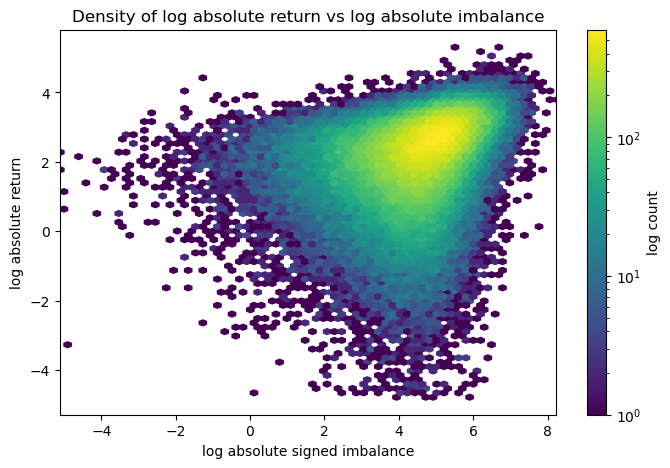

In [7]:


plot_data = analysis[["log_abs_imbalance", "log_abs_return", "signed_current_impact_bps"]].dropna().copy()

plt.figure(figsize=(8, 5))
plt.hexbin(
    plot_data["log_abs_imbalance"],
    plot_data["log_abs_return"],
    gridsize=70,
    bins="log",
    cmap="viridis",
)
plt.colorbar(label="log count")

x_lower, x_upper = plot_data["log_abs_imbalance"].quantile(
    [0.00001, 0.99999]
)

plt.xlim(x_lower, x_upper)

plt.xlabel("log absolute signed imbalance")
plt.ylabel("log absolute return")
plt.title("Density of log absolute return vs log absolute imbalance")

plt.savefig(FIGURE_DIR / "01_log_abs_return_vs_imbalance_hexbin.pdf")

plt.show()

## Diagnostic: binned absolute response

Equal-count bins make the wedge-shaped raw cloud easier to read. This chart shows where a concave association appears, but it still measures absolute price movement rather than signed response to flow.


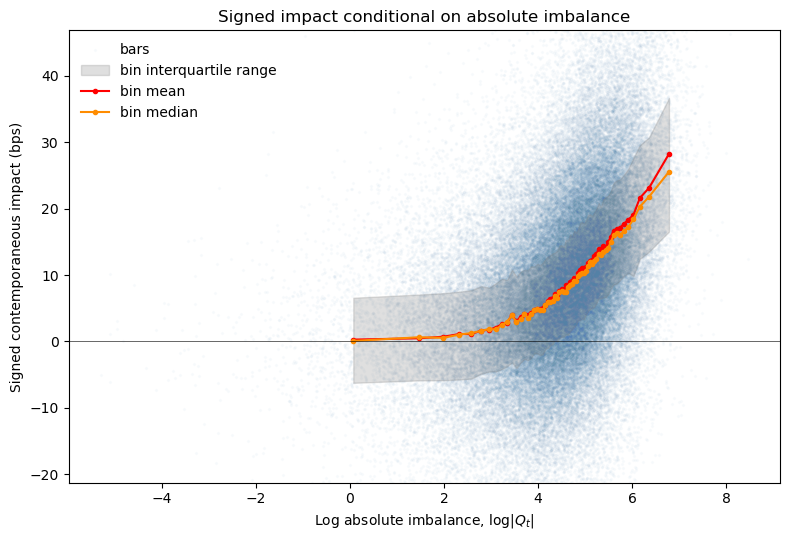

,mean_log_abs_imbalance,mean_current_impact,median_current_impact,p25_current_impact,p75_current_impact,count
0,0.069265,0.280333,0.082227,-6.231540,6.588339,1913
1,1.458215,0.475598,0.633499,-5.869383,7.066997,1913
2,1.986214,0.713935,0.550442,-5.843764,7.277389,1912
3,2.326794,1.122334,1.042962,-5.731243,7.506673,1913
4,2.580910,1.115403,1.267012,-5.596071,7.733747,1913


In [8]:
N_BINS = 60

plot_data["imbalance_bin"] = pd.qcut(
    plot_data["log_abs_imbalance"],
    q=N_BINS,
    duplicates="drop",
)

binned = (
    plot_data
    .groupby("imbalance_bin", observed=True)
    .agg(
        mean_log_abs_imbalance=("log_abs_imbalance", "mean"),
        mean_current_impact=("signed_current_impact_bps", "mean"),
        median_current_impact=("signed_current_impact_bps", "median"),
        p25_current_impact=("signed_current_impact_bps", lambda x: x.quantile(0.25)),
        p75_current_impact=("signed_current_impact_bps", lambda x: x.quantile(0.75)),
        count=("signed_current_impact_bps", "size"),
    )
    .reset_index(drop=True)
)

lower_y, upper_y = plot_data["signed_current_impact_bps"].quantile([0.01, 0.99])

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.scatter(
    plot_data["log_abs_imbalance"],
    plot_data["signed_current_impact_bps"],
    s=2,
    alpha=0.025,
    color="steelblue",
    rasterized=True,
    label="bars",
)

ax.fill_between(
    binned["mean_log_abs_imbalance"],
    binned["p25_current_impact"],
    binned["p75_current_impact"],
    color="grey",
    alpha=0.25,
    label="bin interquartile range",
)

ax.plot(
    binned["mean_log_abs_imbalance"],
    binned["mean_current_impact"],
    marker="o",
    markersize=3,
    color="red",
    linewidth=1.5,
    label="bin mean",
)

ax.plot(
    binned["mean_log_abs_imbalance"],
    binned["median_current_impact"],
    marker="o",
    markersize=3,
    color="darkorange",
    linewidth=1.5,
    label="bin median",
)

ax.axhline(0, color="black", linewidth=0.7, alpha=0.6)
ax.set_ylim(lower_y, upper_y)

ax.set_xlabel(r"Log absolute imbalance, $\log |Q_t|$")
ax.set_ylabel("Signed contemporaneous impact (bps)")
ax.set_title("Signed impact conditional on absolute imbalance")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "02_binned_signed_impact_curve.pdf",
    bbox_inches="tight",
)
plt.show()

binned.head()

In [9]:
analysis.head()

,end_time,start_price,end_price,high_price,low_price,gross_volume,signed_imbalance,trade_count,duration_seconds,log_return_bps,abs_signed_imbalance,absolute_imbalance_ratio,high_low_range_bps,source_file,events_per_bar,signed_imbalance_ratio,log_duration,log_gross_volume,log_range,current_return_bps,future_return_1_bps,signed_future_return_1_bps,future_return_2_bps,signed_future_return_2_bps,future_return_3_bps,signed_future_return_3_bps,future_return_5_bps,signed_future_return_5_bps,signed_current_return_bps,log_abs_return,log_abs_imbalance,log_absolute_imbalance_ratio,trailing_market_volume,trailing_realised_volatility_bps,signed_current_impact_bps,normalised_imbalance,normalised_signed_impact,flow_rate_btc_per_second,trailing_volume_rate_btc_per_second,flow_rate_ratio,normalised_total_impact_0,normalised_post_response_0,normalised_post_response_1,normalised_total_impact_1,normalised_post_response_2,normalised_total_impact_2,normalised_post_response_3,normalised_total_impact_3,normalised_post_response_5,normalised_total_impact_5,absolute_imbalance_ratio_regime,activity_regime,duration_regime,volume_regime,volatility_regime,flow_rate_regime,normalised_imbalance_regime,utc_block,block_day
start_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00.051000+00:00,2025-01-01 00:10:43.392000+00:00,"93,548.800000","93,564.900000","93,690.000000","93,514.200000",574.543000,-69.839000,4000,643.341000,1.720879,69.839000,0.121556,18.781635,BTCUSDT-trades-2025-01.parquet,4000,-0.121556,6.466675,6.353575,2.932880,1.720879,24.338470,-24.338470,15.410570,-15.410570,34.078599,-34.078599,66.374718,-66.374718,-1.720879,0.542835,4.246193,-2.107382,NaN,NaN,-1.720879,NaN,NaN,0.893061,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,medium,low_activity,very_long_duration,low_volume,medium_volatility,NaN,NaN,00-08,2025-01-01 00:00:00+00:00
2025-01-01 00:10:43.406000+00:00,2025-01-01 00:18:05.474000+00:00,"93,564.900000","93,792.900000","93,810.000000","93,460.200000",809.902000,-50.536000,4000,442.068000,24.338470,50.536000,0.062398,37.357829,BTCUSDT-trades-2025-01.parquet,4000,-0.062398,6.091464,6.696913,3.620543,24.338470,-8.927901,8.927901,9.740129,-9.740129,16.735657,-16.735657,53.920295,-53.920295,-24.338470,3.192058,3.922686,-2.774227,NaN,NaN,-24.338470,NaN,NaN,1.832076,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low,medium_activity,long_duration,high_volume,high_volatility,NaN,NaN,00-08,2025-01-01 00:00:00+00:00
2025-01-01 00:18:05.501000+00:00,2025-01-01 00:28:55.065000+00:00,"93,792.900000","93,709.200000","93,884.900000","93,680.000000",649.428000,24.506000,4000,649.564000,-8.927901,24.506000,0.037735,21.848446,BTCUSDT-trades-2025-01.parquet,4000,0.037735,6.476301,6.476092,3.084130,-8.927901,18.668030,18.668030,25.663557,25.663557,50.964148,50.964148,19.083426,19.083426,-8.927901,2.189181,3.198918,-3.277174,NaN,NaN,-8.927901,NaN,NaN,0.999791,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,very_low,low_activity,very_long_duration,medium_volume,medium_volatility,NaN,NaN,00-08,2025-01-01 00:00:00+00:00
2025-01-01 00:28:55.142000+00:00,2025-01-01 00:38:47.103000+00:00,"93,709.200000","93,884.300000","93,948.700000","93,709.200000",929.054000,91.210000,4000,591.961000,18.668030,91.210000,0.098175,25.525185,BTCUSDT-trades-2025-01.parquet,4000,0.098175,6.383441,6.834167,3.239666,18.668030,6.995528,6.995528,32.296118,32.296118,44.180166,44.180166,26.486898,26.486898,18.668030,2.926812,4.513165,-2.321002,NaN,NaN,18.668030,NaN,NaN,1.569451,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low,low_activity,long_duration,high_volume,medium_volatility,NaN,NaN,00-08,2025-01-01 00:00:00+00:00
2025-01-01 00:38:47.192000+00:00,2025-01-01 00:50:32.026000+00:00,"93,884.300000","93,950.000000","93,957.800000","93,834.800000",529.284000,43.542000,4000,704.834000,6.995528,43.542000,0.082266,13.099560,BTCUSDT-trades-2025-01.parquet,4000,0.082266,6.557962,6.271525,2.572579,6.995528,25.300591,25.300591,37.184638,

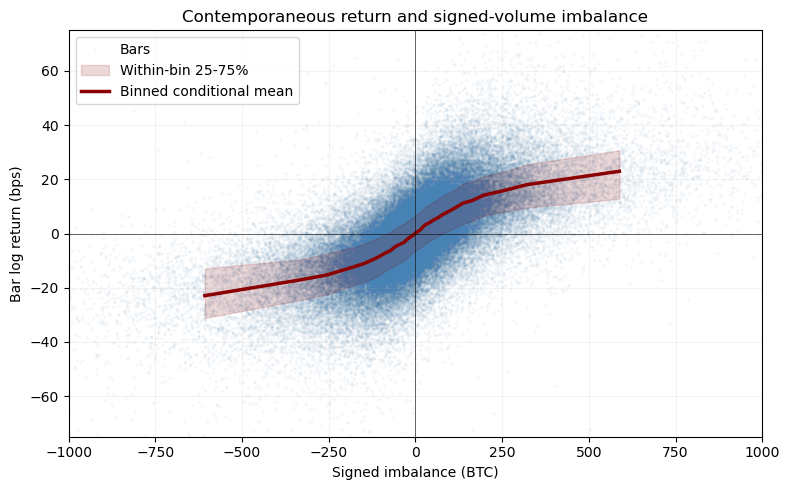

,mean_signed_imbalance,mean_log_return,median_log_return,p25_log_return,p75_log_return,count
0,-607.310412,-22.933031,-21.612115,-31.148890,-12.899479,3827
1,-335.478547,-17.179472,-16.293702,-24.647517,-9.550753,3827
2,-255.636411,-15.308248,-14.582770,-22.480251,-7.447659,3827
3,-208.435547,-13.482944,-12.789725,-20.412534,-5.863967,3827
4,-174.232716,-12.145343,-11.517180,-18.747925,-5.022279,3826


In [10]:
plot_data_2 = analysis[["signed_imbalance", "log_return_bps"]].dropna().copy()

N_BINS = 30

plot_data_2["signed_imbalance_bin"] = pd.qcut(
    plot_data_2["signed_imbalance"],
    q=N_BINS,
    duplicates="drop",
)

binned_2 = (
    plot_data_2
    .groupby("signed_imbalance_bin", observed=True)
    .agg(
        mean_signed_imbalance=("signed_imbalance", "mean"),
        mean_log_return=("log_return_bps", "mean"),
        median_log_return=("log_return_bps", "median"),
        p25_log_return=("log_return_bps", lambda x: x.quantile(0.25)),
        p75_log_return=("log_return_bps", lambda x: x.quantile(0.75)),
        count=("log_return_bps", "size"),
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    plot_data_2["signed_imbalance"],
    plot_data_2["log_return_bps"],
    s=2,
    alpha=0.035,
    color="steelblue",
    rasterized=True,
    label="Bars",
)

ax.fill_between(
    binned_2["mean_signed_imbalance"],
    binned_2["p25_log_return"],
    binned_2["p75_log_return"],
    color="darkred",
    alpha=0.15,
    label="Within-bin 25-75%",
)

ax.plot(
    binned_2["mean_signed_imbalance"],
    binned_2["mean_log_return"],
    #marker="o",
    color='darkred',
    linewidth=2.5,
    label="Binned conditional mean",
)

ax.axhline(0, color="black", linewidth=0.7, alpha=0.6)
ax.axvline(0, color="black", linewidth=0.7, alpha=0.6)

ax.set_xlim(-1000, 1000)
ax.set_ylim(-75, 75)

ax.set_xlabel("Signed imbalance (BTC)")
ax.set_ylabel("Bar log return (bps)")
ax.set_title("Contemporaneous return and signed-volume imbalance")
ax.legend()
ax.grid(alpha=0.15)

fig.tight_layout()

fig.savefig(FIGURE_DIR / "02a_impact_curve.pdf", bbox_inches='tight')

plt.show()

binned_2.head()

## Diagnostic: sensitivity of the absolute-response slope

The low-imbalance region contains substantial price movement unrelated to net signed flow. Dropping early bins illustrates that sensitivity; it is not used to choose the primary model or to maximise $R^2$.


In [10]:
binned.head()

,mean_log_abs_imbalance,mean_current_impact,median_current_impact,p25_current_impact,p75_current_impact,count
0,0.069265,0.280333,0.082227,-6.231540,6.588339,1913
1,1.458215,0.475598,0.633499,-5.869383,7.066997,1913
2,1.986214,0.713935,0.550442,-5.843764,7.277389,1912
3,2.326794,1.122334,1.042962,-5.731243,7.506673,1913
4,2.580910,1.115403,1.267012,-5.596071,7.733747,1913


In [11]:
MIN_BIN_NUMBER = 12
binned_filtered = binned.iloc[MIN_BIN_NUMBER:].copy()

mean_bin_fit = fit_regression(
    data=binned_filtered,
    target="mean_current_impact",
    predictors=["mean_log_abs_imbalance"],
    standardise=[],
    hac_lags=None,
)

median_bin_fit = fit_regression(
    data=binned_filtered,
    target="median_current_impact",
    predictors=["mean_log_abs_imbalance"],
    standardise=[],
    hac_lags=None,
)

mean_slope = mean_bin_fit.model.params["mean_log_abs_imbalance"]
median_slope = median_bin_fit.model.params["mean_log_abs_imbalance"]

print(f"Dropped first {MIN_BIN_NUMBER} of {len(binned)} bins")
print(f"Bars used after bin filter: {binned_filtered['count'].sum():,}")
print(f"Binned mean slope:   {mean_slope:.3f}")
print(f"Binned median slope: {median_slope:.3f}")

Dropped first 12 of 60 bins
Bars used after bin filter: 91,804
Binned mean slope:   7.394
Binned median slope: 6.883


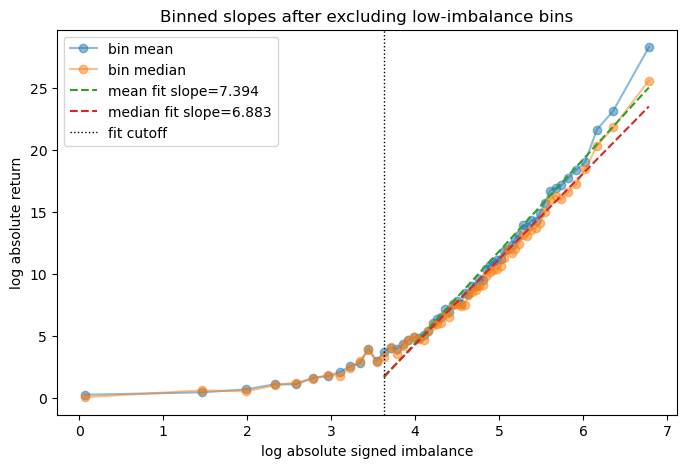

In [12]:
x_grid = np.linspace(
    binned_filtered["mean_log_abs_imbalance"].min(),
    binned_filtered["mean_log_abs_imbalance"].max(),
    100,
)

mean_line = (
    mean_bin_fit.model.params["const"]
    + mean_bin_fit.model.params["mean_log_abs_imbalance"] * x_grid
)
median_line = (
    median_bin_fit.model.params["const"]
    + median_bin_fit.model.params["mean_log_abs_imbalance"] * x_grid
)

plt.figure(figsize=(8, 5))

plt.plot(
    binned["mean_log_abs_imbalance"],
    binned["mean_current_impact"],
    marker="o",
    alpha=0.5,
    label="bin mean",
)
plt.plot(
    binned["mean_log_abs_imbalance"],
    binned["median_current_impact"],
    marker="o",
    alpha=0.5,
    label="bin median",
)
plt.plot(x_grid, mean_line, "--", label=f"mean fit slope={mean_slope:.3f}")
plt.plot(x_grid, median_line, "--", label=f"median fit slope={median_slope:.3f}")
plt.axvline(
    binned.iloc[MIN_BIN_NUMBER]["mean_log_abs_imbalance"],
    color="black",
    linestyle=":",
    linewidth=1,
    label="fit cutoff",
)
plt.xlabel("log absolute signed imbalance")
plt.ylabel("log absolute return")
plt.title("Binned slopes after excluding low-imbalance bins")
plt.legend()

plt.savefig(FIGURE_DIR / "03_binned_slope_fit.pdf")

plt.show()

## Diagnostic: report rather than optimise the cutoff

The table below records how the old absolute-response slope changes across predetermined bin cutoffs. No cutoff is selected from this table for the normalized signed-impact analysis.


In [13]:
rows = []

for min_bin in [0, 3, 6, 9, 12, 15, 18, 21]:
    sample = binned.iloc[min_bin:].copy()
    if len(sample) < 5:
        continue

    mean_fit = fit_regression(
        data=sample,
        target="mean_current_impact",
        predictors=["mean_log_abs_imbalance"],
        standardise=[],
        hac_lags=None,
    )
    median_fit = fit_regression(
        data=sample,
        target="median_current_impact",
        predictors=["mean_log_abs_imbalance"],
        standardise=[],
        hac_lags=None,
    )

    rows.append({
        "min_bin": min_bin,
        "bins_used": len(sample),
        "bars_used": sample["count"].sum(),
        "mean_slope": mean_fit.model.params["mean_log_abs_imbalance"],
        "median_slope": median_fit.model.params["mean_log_abs_imbalance"],
        "mean_r2": mean_fit.model.rsquared,
        "median_r2": median_fit.model.rsquared,
    })

slope_sensitivity = pd.DataFrame(rows)
slope_sensitivity

,min_bin,bins_used,bars_used,mean_slope,median_slope,mean_r2,median_r2
0,0,60,114756,4.595742,4.317554,0.823217,0.831590
1,3,57,109018,5.955194,5.566065,0.929233,0.933935
2,6,54,103279,6.569579,6.130469,0.954708,0.958835
3,9,51,97542,7.004727,6.517945,0.966882,0.970008
4,12,48,91804,7.393950,6.882829,0.977943,0.981906
5,15,45,86066,7.696757,7.130345,0.983831,0.986502
6,18,42,80329,7.939874,7.361132,0.986997,0.990322
7,21,39,74591,8.080090,7.486169,0.986649,0.990485


## Primary estimate: normalized conditional signed impact

For each bar define

$$
x_t=|Q_t|/V^-_{24h},\qquad
y_t=\operatorname{sign}(Q_t)r_t/\sigma^-_{24h}.
$$

The primary curve is $E[y_t\mid x_t]$. Price movements independent of the imbalance direction should tend to cancel in this conditional mean; signing does not, however, separate mechanical impact from news or other common causes of price and order flow.

Thirty equal-count bins give similar precision across the x-range. The conditional mean is the conventional impact object, while the median checks whether the result is dominated by return tails. Ordinary within-bin error bars are shown here; serial dependence is handled by resampling complete days below.


In [14]:
N_IMPACT_BINS = 60
MIN_OBS_PER_FIT_BIN = 500

normalised_sample = analysis[
    ["normalised_imbalance", "normalised_signed_impact"]
].dropna().copy()

normalised_curve = bin_impact_curve_with_uncertainty(
    normalised_sample,
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=N_IMPACT_BINS,
    method="equal_count",
)

normalised_curve[
    [
        "bin_id",
        "mean_x",
        "mean_impact",
        "median_impact",
        "standard_error",
        "n_obs",
    ]
]


,bin_id,mean_x,mean_impact,median_impact,standard_error,n_obs
0,0,0.000007,-0.000051,0.000190,0.000937,1860
1,1,0.000022,0.002876,0.002277,0.000943,1860
2,2,0.000036,0.002914,0.003247,0.000926,1859
3,3,0.000051,0.004463,0.006193,0.000945,1860
4,4,0.000065,0.005478,0.006707,0.000926,1859
5,5,0.000080,0.006241,0.006772,0.000956,1860
6,6,0.000095,0.005054,0.006012,0.000947,1860
7,7,0.000110,0.008937,0.010383,0.000989,1859
8,8,0.000125,0.011430,0.011585,0.000950,1860
9,9,0.000141,0.011622,0.011322,0.000973,1859


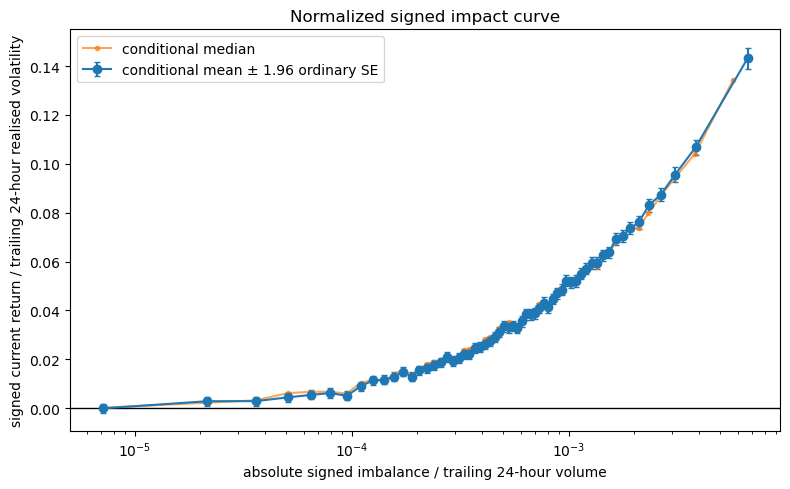

In [15]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    normalised_curve["mean_x"],
    normalised_curve["mean_impact"],
    yerr=1.96 * normalised_curve["standard_error"],
    marker="o",
    capsize=2,
    label="conditional mean ± 1.96 ordinary SE",
)
plt.plot(
    normalised_curve["median_x"],
    normalised_curve["median_impact"],
    marker=".",
    alpha=0.7,
    label="conditional median",
)
plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.xlabel("absolute signed imbalance / trailing 24-hour volume")
plt.ylabel("signed current return / trailing 24-hour realised volatility")
plt.title("Normalized signed impact curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_normalised_signed_impact_curve.pdf", bbox_inches="tight")
plt.show()


## Consistent functional-form comparison

Every subsequent pooled, monthly, bootstrap and regime comparison uses the same estimator: nonlinear weighted least squares in impact levels, with inverse within-bin variance weights.

The alternatives are a fixed square root, a freely estimated power law, a fixed linear response and a two-parameter logarithmic response. Errors are evaluated in impact levels. The logarithmic and free-power models have the same number of fitted parameters, making their error comparison particularly useful.


In [16]:
model_curve = normalised_curve.loc[
    normalised_curve["n_obs"] >= MIN_OBS_PER_FIT_BIN
].copy()

model_comparison, model_predictions = compare_impact_models(
    model_curve,
    min_obs_per_bin=MIN_OBS_PER_FIT_BIN,
)
model_comparison.sort_values("weighted_rmse")


,model,amplitude,delta,curvature,rmse,weighted_rmse,mae,bins_used
3,logarithmic,0.055516,NaN,0.805459,0.001774,0.001331,0.001056,60
1,free_power,3.786991,0.632527,NaN,0.003131,0.002546,0.002248,60
0,square_root,1.537083,0.500000,NaN,0.005815,0.005451,0.004964,60
2,linear,37.574844,1.000000,NaN,0.017858,0.012416,0.011406,60


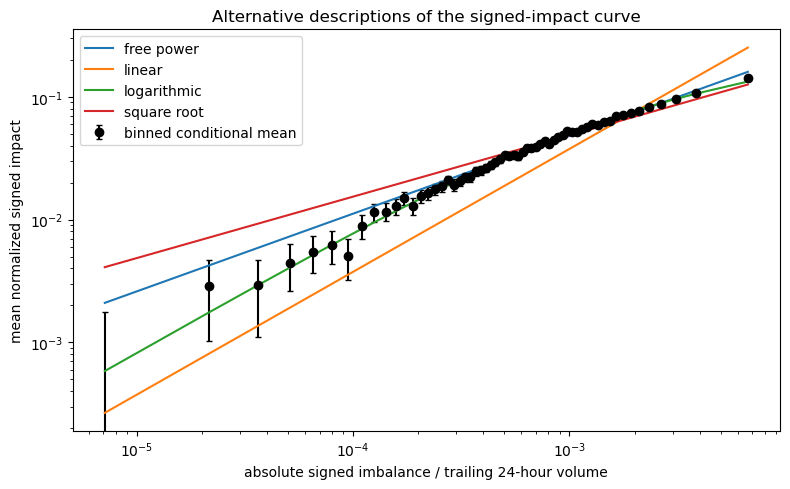

In [17]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    model_curve["mean_x"],
    model_curve["mean_impact"],
    yerr=1.96 * model_curve["standard_error"],
    fmt="o",
    color="black",
    capsize=2,
    label="binned conditional mean",
)
for model, group in model_predictions.groupby("model", observed=True):
    group = group.sort_values("x")
    plt.plot(group["x"], group["predicted_impact"], label=model.replace("_", " "))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("absolute signed imbalance / trailing 24-hour volume")
plt.ylabel("mean normalized signed impact")
plt.title("Alternative descriptions of the signed-impact curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_normalised_impact_model_comparison.pdf", bbox_inches="tight")
plt.show()


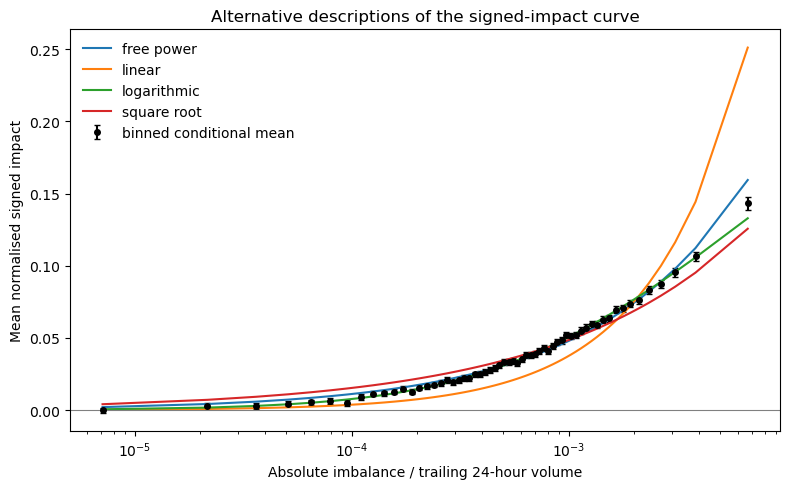

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

confidence_multiplier = 1.96
yerr = confidence_multiplier * model_curve["standard_error"]

ax.errorbar(
    model_curve["mean_x"],
    model_curve["mean_impact"],
    yerr=yerr,
    fmt="o",
    color="black",
    markersize=4,
    capsize=2,
    label="binned conditional mean",
)

for model, group in model_predictions.groupby("model", observed=True):
    group = group.sort_values("x")
    ax.plot(
        group["x"],
        group["predicted_impact"],
        label=model.replace("_", " "),
    )

ax.set_xscale("log")
ax.axhline(0, color="grey", linewidth=0.8)

ax.set_xlabel(
    "Absolute imbalance / trailing 24-hour volume"
)
ax.set_ylabel("Mean normalised signed impact")
ax.set_title("Alternative descriptions of the signed-impact curve")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "05_linear_axis_normalised_impact_model_comparison.pdf",
    bbox_inches="tight",
)
plt.show()

### Residual structure

The standardized residual is $(\bar{y}-\hat{y})/\operatorname{SE}(\bar{y})$. A satisfactory curve should leave residuals without a systematic shape across normalized imbalance. Long runs above or below zero indicate that the functional form is missing curvature even when its overall error is small.


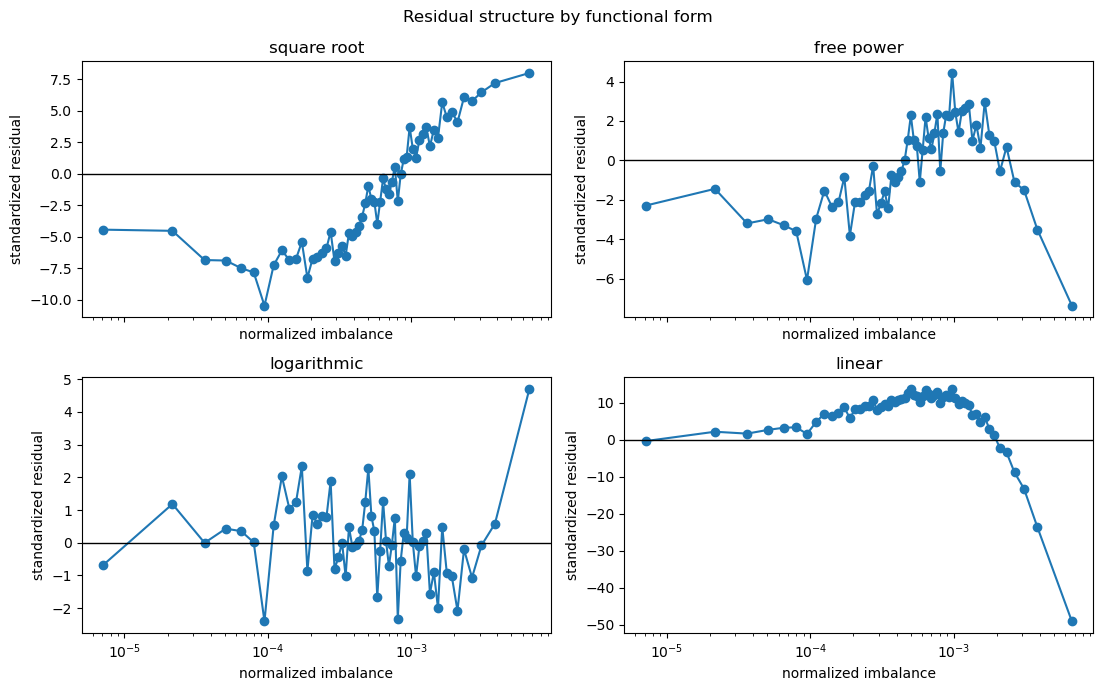

In [19]:
observed_bins = model_curve[
    ["mean_x", "mean_impact", "standard_error"]
].rename(columns={"mean_x": "x"})
model_residuals = model_predictions.merge(observed_bins, on="x", how="left")
model_residuals["standardised_residual"] = (
    model_residuals["mean_impact"] - model_residuals["predicted_impact"]
) / model_residuals["standard_error"]

model_order = ["square_root", "free_power", "logarithmic", "linear"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for model, ax in zip(model_order, axes.ravel(), strict=True):
    group = model_residuals.loc[model_residuals["model"] == model].sort_values("x")
    ax.plot(group["x"], group["standardised_residual"], marker="o")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xscale("log")
    ax.set_title(model.replace("_", " "))
    ax.set_ylabel("standardized residual")
    ax.set_xlabel("normalized imbalance")

fig.suptitle("Residual structure by functional form")
fig.tight_layout()
plt.savefig(FIGURE_DIR / "05b_model_standardised_residuals.pdf", bbox_inches="tight")
plt.show()


## Stability across months using the same estimator

Each month is independently rebinned and evaluated with the same weighted level-fit comparison used for the pooled sample. The table reports both the free-power exponent and the difference

$$
\mathrm{WRMSE}_{log}-\mathrm{WRMSE}_{power}.
$$

A negative difference means that the logarithmic curve fits that month better. Monthly x-ranges and sample sizes should be considered when interpreting unstable estimates.


In [20]:
monthly_analysis = analysis.copy()
monthly_rows = []

monthly_analysis["calendar_month"] = (
    monthly_analysis.index
    .tz_localize(None).to_period("M")
                                   )

for calendar_month, month in monthly_analysis.groupby(
    "calendar_month",
    observed=True,
):
    month_sample = month[
            ["normalised_imbalance", "normalised_signed_impact"]
        ].dropna()
    if len(month_sample) < 2_000:
            continue

    month_curve = bin_impact_curve_with_uncertainty(
        month_sample,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=20,
        method="equal_count",
    )
    try:
        month_comparison, _ = compare_impact_models(
            month_curve,
            min_obs_per_bin=100,
        )
    except (RuntimeError, ValueError):
        continue

    fitted = month_comparison.set_index("model")
    monthly_rows.append(
        {
            "calendar_month": str(calendar_month),
            "observations": len(month_sample),
            "min_x": month_sample["normalised_imbalance"].min(),
            "max_x": month_sample["normalised_imbalance"].max(),
            "free_power_delta": fitted.loc["free_power", "delta"],
            "free_power_weighted_rmse": fitted.loc["free_power", "weighted_rmse"],
            "logarithmic_curvature": fitted.loc["logarithmic", "curvature"],
            "logarithmic_weighted_rmse": fitted.loc["logarithmic", "weighted_rmse"],
            "square_root_weighted_rmse": fitted.loc["square_root", "weighted_rmse"],
            "log_relative_improvement_pct": 100 * (
                (- fitted.loc["logarithmic", "weighted_rmse"]
                + fitted.loc["free_power", "weighted_rmse"] 
                ) / fitted.loc["free_power", "weighted_rmse"] 
            ),
        }
    )

monthly_model_comparison = pd.DataFrame(monthly_rows)
monthly_model_comparison

,calendar_month,observations,min_x,max_x,free_power_delta,free_power_weighted_rmse,logarithmic_curvature,logarithmic_weighted_rmse,square_root_weighted_rmse,log_relative_improvement_pct
0,2025-01,8380,0.000000,0.017751,0.651784,0.003236,0.764391,0.002413,0.005994,25.442092
1,2025-02,6952,0.000000,0.017213,0.633116,0.003202,0.907053,0.002236,0.005547,30.161712
2,2025-03,8614,0.000000,0.012055,0.659970,0.003211,0.737400,0.002209,0.006071,31.200095
3,2025-04,7668,0.000000,0.018723,0.620199,0.003576,0.871836,0.001853,0.005534,48.170664
4,2025-05,6723,0.000000,0.026590,0.669701,0.004436,0.671414,0.002371,0.007834,46.541446
5,2025-06,5522,0.000000,0.017288,0.658907,0.003598,0.762125,0.003051,0.007318,15.204363
6,2025-07,5453,0.000001,0.029701,0.645508,0.004247,0.851175,0.002688,0.006986,36.724112
7,2025-08,5423,0.000000,0.025988,0.620922,0.003644,1.030889,0.002633,0.005859,27.726318
8,2025-09,3802,0.000000,0.021023,0.657801,0.005173,0.707734,0.004070,0.008386,21.331099
9,2025-10,7248,0.000000,0.030552,0.641534,0.003208,0.806928,0.002452,0.005786,23.566607


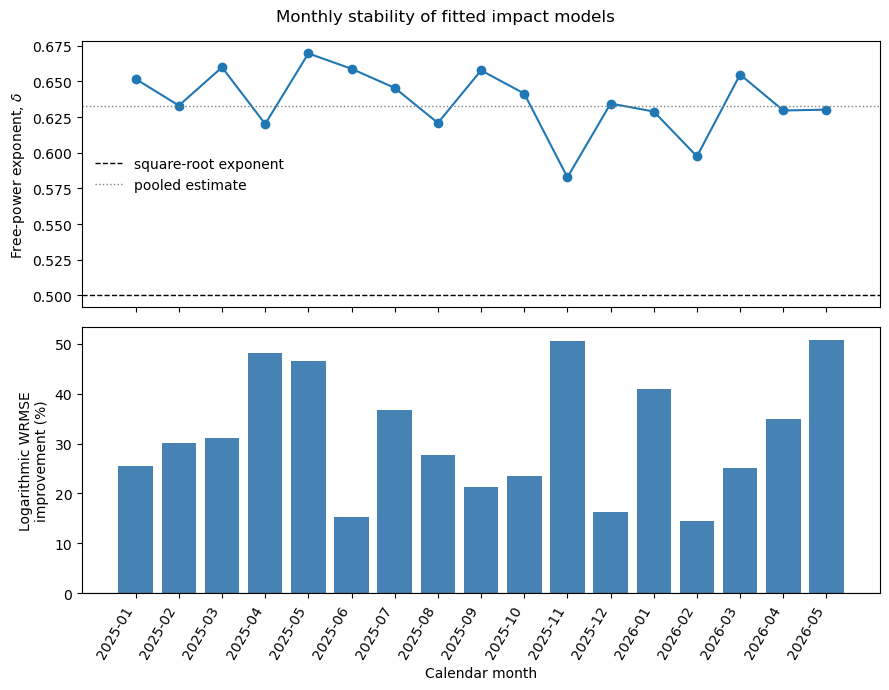

In [21]:
monthly_model_comparison = (
    pd.DataFrame(monthly_rows)
    .sort_values("calendar_month")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True,
)

positions = np.arange(len(monthly_model_comparison))
labels = monthly_model_comparison["calendar_month"]

axes[0].plot(
    positions,
    monthly_model_comparison["free_power_delta"],
    marker="o",
    linewidth=1.5,
)

axes[0].axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="square-root exponent",
)

axes[0].axhline(
    model_comparison
    .set_index("model")
    .loc["free_power", "delta"],
    color="grey",
    linestyle=":",
    linewidth=1,
    label="pooled estimate",
)

axes[0].set_ylabel(r"Free-power exponent, $\delta$")
axes[0].legend(frameon=False)

axes[1].bar(
    positions,
    monthly_model_comparison["log_relative_improvement_pct"],
    color="steelblue",
)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Logarithmic WRMSE\nimprovement (%)")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels, rotation=60, ha="right")
axes[1].set_xlabel("Calendar month")

fig.suptitle("Monthly stability of fitted impact models")
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "06_monthly_model_stability.pdf",
    bbox_inches="tight",
)

plt.show()

In [22]:
monthly_summary = pd.Series(
    {
        "months": len(monthly_model_comparison),
        "mean_delta": monthly_model_comparison[
            "free_power_delta"
        ].mean(),
        "sd_delta": monthly_model_comparison[
            "free_power_delta"
        ].std(),
        "minimum_delta": monthly_model_comparison[
            "free_power_delta"
        ].min(),
        "maximum_delta": monthly_model_comparison[
            "free_power_delta"
        ].max(),
        "months_log_better": (
            monthly_model_comparison[
                "log_relative_improvement_pct"
            ] > 0
        ).sum(),
        "median_log_improvement_pct": monthly_model_comparison[
            "log_relative_improvement_pct"
        ].median(),
    }
)

monthly_summary

months                       17.000000
mean_delta                    0.636349
sd_delta                      0.022868
minimum_delta                 0.582753
maximum_delta                 0.669701
months_log_better            17.000000
median_log_improvement_pct   30.161712
dtype: float64

## Day-block bootstrap of the complete estimator

Bars are serially dependent, so the bootstrap resamples complete UTC days. Every bootstrap sample reconstructs the equal-count curve and repeats the same weighted level-fit comparison.

The output gives an uncertainty interval for the free-power exponent and the frequency with which the logarithmic curve beats the free power law. This evaluates estimator stability; it does not turn the aggregate-flow association into a causal impact estimate.


In [23]:
N_BOOTSTRAP = 200

bootstrap_results = block_bootstrap_impact_models(
    analysis,
    block_col="block_day",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=N_IMPACT_BINS,
    n_bootstrap=N_BOOTSTRAP,
    min_obs_per_bin=MIN_OBS_PER_FIT_BIN,
    random_state=2026,
)

bootstrap_summary = pd.Series(
    {
        "successful_samples": len(bootstrap_results),
        "median_free_power_delta": bootstrap_results["free_power_delta"].median(),
        "delta_ci_2.5%": bootstrap_results["free_power_delta"].quantile(0.025),
        "delta_ci_97.5%": bootstrap_results["free_power_delta"].quantile(0.975),
        "median_log_minus_power_wrmse": bootstrap_results[
            "log_minus_power_weighted_rmse"
        ].median(),
        "probability_log_better": (
            bootstrap_results["log_minus_power_weighted_rmse"] < 0
        ).mean(),
    },
    name="day-block bootstrap",
)
bootstrap_summary


successful_samples             200.000000
median_free_power_delta          0.631919
delta_ci_2.5%                    0.622717
delta_ci_97.5%                   0.642212
median_log_minus_power_wrmse    -0.001049
probability_log_better           1.000000
Name: day-block bootstrap, dtype: float64

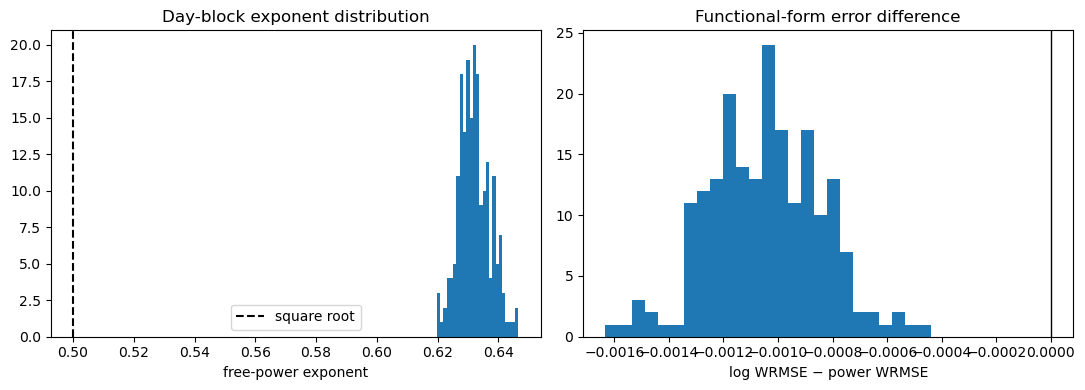

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(bootstrap_results["free_power_delta"], bins=25)
axes[0].axvline(0.5, color="black", linestyle="--", label="square root")
axes[0].set_xlabel("free-power exponent")
axes[0].set_title("Day-block exponent distribution")
axes[0].legend()

axes[1].hist(bootstrap_results["log_minus_power_weighted_rmse"], bins=25)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("log WRMSE − power WRMSE")
axes[1].set_title("Functional-form error difference")

fig.tight_layout()
plt.show()


## Liquidity-state comparisons on common support

Volume, flow rate and duration describe different aspects of market activity:

- gross volume is BTC traded in the fixed 4,000-event bar;
- flow rate is gross BTC per second relative to the trailing 24-hour average BTC-per-second rate;
- duration is the clock time needed to accumulate the 4,000 events.

All regime curves below use pooled normalized-imbalance edges. Model comparisons retain only bins represented in every regime, so differences are not produced solely by fitting different x-ranges.


### Gross-volume state

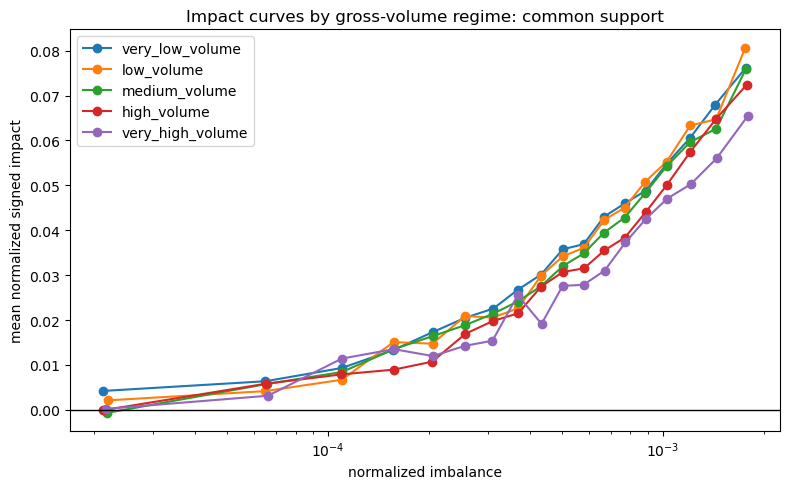

,volume_regime,model,delta,weighted_rmse,bins_used
15,high_volume,logarithmic,NaN,0.001305,18
13,high_volume,free_power,0.771487,0.001628,18
14,high_volume,linear,1.000000,0.004576,18
12,high_volume,square_root,0.500000,0.006289,18
7,low_volume,logarithmic,NaN,0.001760,18
5,low_volume,free_power,0.757436,0.002169,18
6,low_volume,linear,1.000000,0.005124,18
4,low_volume,square_root,0.500000,0.006109,18
11,medium_volume,logarithmic,NaN,0.001159,18
9,medium_volume,free_power,0.725372,0.001607,18


In [25]:
volume_order = [
    "very_low_volume", "low_volume", "medium_volume", "high_volume", "very_high_volume"
]
volume_curves, _ = bin_impact_by_shared_edges(
    analysis,
    regime_col="volume_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)
volume_model_comparison, _, common_volume_curves = compare_impact_models_by_regime(
    volume_curves,
    regime_col="volume_regime",
    regimes=volume_order,
    min_obs_per_bin=200,
)

plt.figure(figsize=(8, 5))
for regime in volume_order:
    group = common_volume_curves.loc[common_volume_curves["volume_regime"] == regime]
    plt.plot(group["mean_x"], group["mean_impact"], marker="o", label=regime)
plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.xlabel("normalized imbalance")
plt.ylabel("mean normalized signed impact")
plt.title("Impact curves by gross-volume regime: common support")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_volume_regime_scaling_collapse.pdf", bbox_inches="tight")
plt.show()

volume_model_comparison[
    ["volume_regime", "model", "delta", "weighted_rmse", "bins_used"]
].sort_values(["volume_regime", "weighted_rmse"])


### Normalized flow-rate state

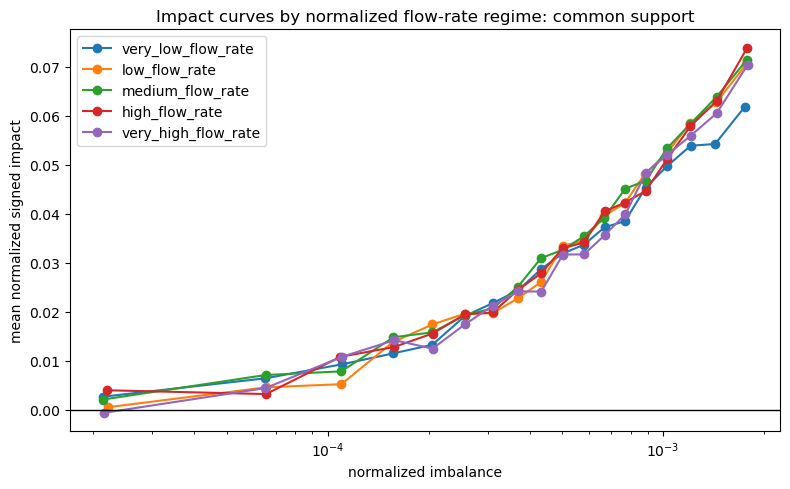

,flow_rate_regime,model,delta,weighted_rmse,bins_used
15,high_flow_rate,logarithmic,NaN,0.001399,18
13,high_flow_rate,free_power,0.700604,0.001534,18
12,high_flow_rate,square_root,0.500000,0.005053,18
14,high_flow_rate,linear,1.000000,0.006138,18
7,low_flow_rate,logarithmic,NaN,0.001680,18
5,low_flow_rate,free_power,0.721327,0.002357,18
4,low_flow_rate,square_root,0.500000,0.005571,18
6,low_flow_rate,linear,1.000000,0.005841,18
11,medium_flow_rate,logarithmic,NaN,0.001104,18
9,medium_flow_rate,free_power,0.679845,0.001706,18


In [26]:
flow_rate_order = [
    "very_low_flow_rate", "low_flow_rate", "medium_flow_rate",
    "high_flow_rate", "very_high_flow_rate"
]
flow_rate_curves, _ = bin_impact_by_shared_edges(
    analysis,
    regime_col="flow_rate_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)
flow_rate_model_comparison, _, common_flow_rate_curves = compare_impact_models_by_regime(
    flow_rate_curves,
    regime_col="flow_rate_regime",
    regimes=flow_rate_order,
    min_obs_per_bin=200,
)

plt.figure(figsize=(8, 5))
for regime in flow_rate_order:
    group = common_flow_rate_curves.loc[
        common_flow_rate_curves["flow_rate_regime"] == regime
    ]
    plt.plot(group["mean_x"], group["mean_impact"], marker="o", label=regime)
plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.xlabel("normalized imbalance")
plt.ylabel("mean normalized signed impact")
plt.title("Impact curves by normalized flow-rate regime: common support")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_flow_rate_regime_impact_curves.pdf", bbox_inches="tight")
plt.show()

flow_rate_model_comparison[
    ["flow_rate_regime", "model", "delta", "weighted_rmse", "bins_used"]
].sort_values(["flow_rate_regime", "weighted_rmse"])


### Duration state

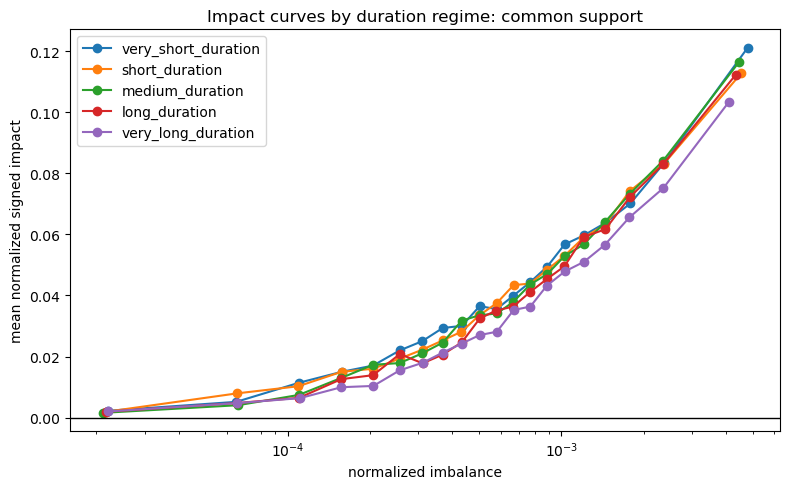

,duration_regime,model,delta,weighted_rmse,bins_used
15,long_duration,logarithmic,NaN,0.001766,20
13,long_duration,free_power,0.663292,0.003079,20
12,long_duration,square_root,0.500000,0.006238,20
14,long_duration,linear,1.000000,0.010508,20
11,medium_duration,logarithmic,NaN,0.001359,20
9,medium_duration,free_power,0.635949,0.002839,20
8,medium_duration,square_root,0.500000,0.005694,20
10,medium_duration,linear,1.000000,0.012034,20
7,short_duration,logarithmic,NaN,0.001267,20
5,short_duration,free_power,0.598943,0.002864,20


In [27]:
duration_order = [
    "very_short_duration", "short_duration", "medium_duration",
    "long_duration", "very_long_duration"
]
duration_curves, _ = bin_impact_by_shared_edges(
    analysis,
    regime_col="duration_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)
duration_model_comparison, _, common_duration_curves = compare_impact_models_by_regime(
    duration_curves,
    regime_col="duration_regime",
    regimes=duration_order,
    min_obs_per_bin=200,
)

plt.figure(figsize=(8, 5))
for regime in duration_order:
    group = common_duration_curves.loc[
        common_duration_curves["duration_regime"] == regime
    ]
    plt.plot(group["mean_x"], group["mean_impact"], marker="o", label=regime)
plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.xlabel("normalized imbalance")
plt.ylabel("mean normalized signed impact")
plt.title("Impact curves by duration regime: common support")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_duration_regime_impact_curves.pdf", bbox_inches="tight")
plt.show()

duration_model_comparison[
    ["duration_regime", "model", "delta", "weighted_rmse", "bins_used"]
].sort_values(["duration_regime", "weighted_rmse"])


## Normalized impact trajectories after the imbalance bar

For horizon $h$, total signed impact from the current bar start through the end of bar $t+h$ is

$$
I_t(h)=\frac{\operatorname{sign}(Q_t)r_t+
\operatorname{sign}(Q_t)r_{t\rightarrow t+h}}
{\sigma^-_{24h}}.
$$

The fraction remaining is the ratio of conditional means, $E[I(h)]/E[I(0)]$. A value below one indicates partial reversal; above one indicates continuation. It is deliberately not the mean of individual ratios, which would be unstable whenever initial impact is close to zero.

Horizons are numbers of 4,000-event bars rather than fixed clock time. This is market-event time and must not yet be interpreted as an execution schedule in minutes.


In [28]:
trajectory_horizons = [0, *HORIZONS]

trajectory_by_imbalance = summarise_normalised_impact_trajectory(
    analysis,
    group_cols=["normalised_imbalance_regime"],
    horizons=trajectory_horizons,
)
trajectory_by_flow_rate = summarise_normalised_impact_trajectory(
    analysis,
    group_cols=["flow_rate_regime"],
    horizons=trajectory_horizons,
)
trajectory_by_imbalance_and_flow = summarise_normalised_impact_trajectory(
    analysis,
    group_cols=["normalised_imbalance_regime", "flow_rate_regime"],
    horizons=trajectory_horizons,
)

trajectory_by_imbalance


,normalised_imbalance_regime,horizon,count,mean_total_impact,median_total_impact,impact_std,standard_error,mean_initial_impact,fraction_remaining,fraction_reversed
0,very_low_imbalance,0,22316,0.007232,0.007635,0.041236,0.000276,0.007232,1.000000,0.000000
1,very_low_imbalance,1,22316,0.006641,0.006916,0.073233,0.000490,0.007232,0.918277,0.081723
2,very_low_imbalance,2,22316,0.006321,0.007671,0.094767,0.000634,0.007232,0.874050,0.125950
3,very_low_imbalance,3,22316,0.006344,0.006999,0.112231,0.000751,0.007232,0.877179,0.122821
4,very_low_imbalance,5,22316,0.005527,0.007971,0.140128,0.000938,0.007232,0.764214,0.235786
5,low_imbalance,0,22315,0.019712,0.020538,0.043145,0.000289,0.019712,1.000000,0.000000
6,low_imbalance,1,22315,0.019278,0.020536,0.076267,0.000511,0.019712,0.977966,0.022034
7,low_imbalance,2,22315,0.019220,0.021488,0.097926,0.000656,0.019712,0.975015,0.024985
8,low_imbalance,3,22315,0.019098,0.020580,0.115563,0.000774,0.019712,0.968845,0.031155
9,low_imbalance,5,22315,0.019167,0.020872,0.144964,0.000970,0.019712,0.972331,0.027669


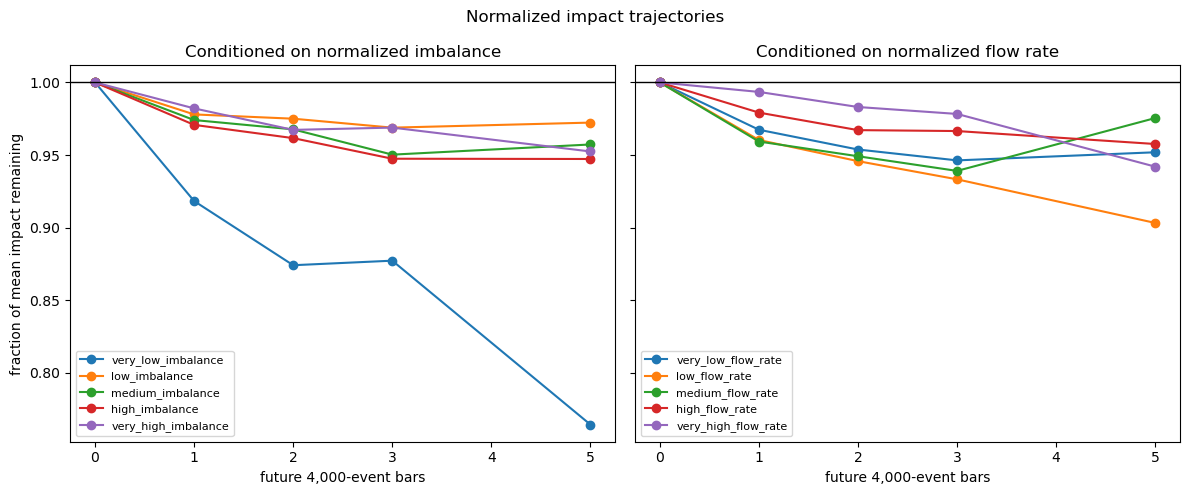

In [29]:
imbalance_order = [
    "very_low_imbalance", "low_imbalance", "medium_imbalance",
    "high_imbalance", "very_high_imbalance"
]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for regime in imbalance_order:
    group = trajectory_by_imbalance.loc[
        trajectory_by_imbalance["normalised_imbalance_regime"] == regime
    ]
    axes[0].plot(group["horizon"], group["fraction_remaining"], marker="o", label=regime)
axes[0].axhline(1, color="black", linewidth=1)
axes[0].set_title("Conditioned on normalized imbalance")
axes[0].set_xlabel("future 4,000-event bars")
axes[0].set_ylabel("fraction of mean impact remaining")

for regime in flow_rate_order:
    group = trajectory_by_flow_rate.loc[
        trajectory_by_flow_rate["flow_rate_regime"] == regime
    ]
    axes[1].plot(group["horizon"], group["fraction_remaining"], marker="o", label=regime)
axes[1].axhline(1, color="black", linewidth=1)
axes[1].set_title("Conditioned on normalized flow rate")
axes[1].set_xlabel("future 4,000-event bars")

axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
fig.suptitle("Normalized impact trajectories")
fig.tight_layout()
plt.savefig(FIGURE_DIR / "09_normalised_impact_trajectories.pdf", bbox_inches="tight")
plt.show()


In [30]:
horizon_to_display = max(HORIZONS)
trajectory_state_table = trajectory_by_imbalance_and_flow.loc[
    trajectory_by_imbalance_and_flow["horizon"] == horizon_to_display
].pivot(
    index="normalised_imbalance_regime",
    columns="flow_rate_regime",
    values="fraction_remaining",
).reindex(index=imbalance_order, columns=flow_rate_order)

trajectory_state_table


flow_rate_regime,very_low_flow_rate,low_flow_rate,medium_flow_rate,high_flow_rate,very_high_flow_rate
normalised_imbalance_regime,,,,,
very_low_imbalance,1.045002,0.687019,0.803101,0.595026,0.208298
low_imbalance,0.962051,0.962633,1.019554,0.945759,0.972523
medium_imbalance,0.954967,0.922468,1.021611,0.973182,0.892518
high_imbalance,0.874064,0.881279,0.969601,1.017091,0.956645
very_high_imbalance,1.045286,0.916086,0.962367,0.943290,0.956207


## Interpretation and limits

The central result is a smooth, monotonic and concave normalized signed-flow response. Mean and median impact should be considered together to establish whether the result is broad-based rather than tail-driven. The free-power exponent is an interpretable summary elasticity, while the logarithmic-versus-power error comparison tests whether that elasticity is actually constant.

The monthly, day-block and common-support regime sections determine how stable this description is. In particular, persistent separation by flow rate would show that volume and imbalance alone do not characterize liquidity: the speed at which flow arrives changes the response.

The trajectory section is a first estimate of response over market-event time. It distinguishes continuation from partial reversal and conditions that behaviour on imbalance and flow-rate state. It is not yet an optimal-execution cost model because:

- the bars contain anonymous aggregate flow rather than identified parent orders;
- contemporaneous association does not establish the causal effect of adding a firm's order;
- transaction prices include bid-offer and endpoint effects;
- BTCUSDT perpetual-futures flow can include liquidations and basis-related activity;
- the trajectory horizons are event bars, not clock time;
- trajectory uncertainty still needs a block-bootstrap extension.

The defensible conclusion is evidence for a state-dependent concave aggregate-flow response. The next practical extension is to estimate the same trajectory in clock time, add spread and fee estimates, and relate a proposed firm's participation rate to expected cost and inventory risk.


In [31]:
analysis["event_speed_regime"] = pd.qcut(
    analysis["duration_seconds"],
    q=5,
    labels=[
        "very_fast",
        "fast",
        "medium",
        "slow",
        "very_slow",
    ],
)

In [32]:
speed_curves, speed_edges = bin_impact_by_shared_edges(
    analysis,
    regime_col="event_speed_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)

pooled_x_scale = float(analysis["normalised_imbalance"].dropna().median())

In [33]:
speed_order = [
    "very_fast",
    "fast",
    "medium",
    "slow",
    "very_slow",
]

speed_model_comparison, speed_predictions, common_speed_curves = (
    compare_impact_models_by_regime(
        speed_curves,
        regime_col="event_speed_regime",
        regimes=speed_order,
        min_obs_per_bin=200,
        require_common_bins=True,
        x_scale=pooled_x_scale,
    )
)

In [37]:
regime_summary = (
    speed_model_comparison
    .pivot(
        index="event_speed_regime",
        columns="model",
        values=[
            "amplitude",
            "delta",
            "curvature",
            "weighted_rmse",
        ],
    )
)

log_A = regime_summary[("amplitude", "logarithmic")]
log_b = regime_summary[("curvature", "logarithmic")]

regime_parameters = pd.DataFrame(
    {
        "log_amplitude": log_A,
        "log_curvature": log_b,
        "log_x0": pooled_x_scale / log_b,
        "free_power_delta": regime_summary[
            ("delta", "free_power")
        ],
        "log_wrmse": regime_summary[
            ("weighted_rmse", "logarithmic")
        ],
        "power_wrmse": regime_summary[
            ("weighted_rmse", "free_power")
        ],
    }
)

regime_parameters["initial_marginal_impact"] = (
    regime_parameters["log_amplitude"]
    / regime_parameters["log_x0"]
)

regime_parameters["initial_effective_liquidity"] = (
    regime_parameters["log_x0"]
    / regime_parameters["log_amplitude"]
)

regime_parameters["log_wrmse_improvement_pct"] = 100 * (
    regime_parameters["power_wrmse"]
    - regime_parameters["log_wrmse"]
) / regime_parameters["power_wrmse"]

regime_parameters

,log_amplitude,log_curvature,log_x0,free_power_delta,log_wrmse,power_wrmse,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
event_speed_regime,,,,,,,,,
fast,0.048622,1.055449,0.000512,0.598943,0.001267,0.002864,94.977240,0.010529,55.743933
medium,0.055087,0.839987,0.000643,0.635949,0.001359,0.002839,85.638052,0.011677,52.124058
slow,0.059296,0.708061,0.000763,0.663292,0.001766,0.003079,77.704704,0.012869,42.638630
very_fast,0.048686,1.085896,0.000498,0.586229,0.001986,0.002655,97.845532,0.010220,25.205053
very_slow,0.058264,0.631594,0.000855,0.684761,0.001135,0.002449,68.106273,0.014683,53.666072


In [38]:
reference_x = float(
    analysis["normalised_imbalance"].quantile(0.90)
)

regime_parameters["impact_at_reference_x"] = (
    regime_parameters["log_amplitude"]
    * np.log1p(
        reference_x / regime_parameters["log_x0"]
    )
)

z = reference_x / regime_parameters["log_x0"]

regime_parameters["elasticity_at_reference_x"] = (
    (z / (1 + z)) / np.log1p(z)
)

regime_parameters

,log_amplitude,log_curvature,log_x0,free_power_delta,log_wrmse,power_wrmse,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct,impact_at_reference_x,elasticity_at_reference_x
event_speed_regime,,,,,,,,,,,
fast,0.048622,1.055449,0.000512,0.598943,0.001267,0.002864,94.977240,0.010529,55.743933,0.077415,0.500268
medium,0.055087,0.839987,0.000643,0.635949,0.001359,0.002839,85.638052,0.011677,52.124058,0.077932,0.535092
slow,0.059296,0.708061,0.000763,0.663292,0.001766,0.003079,77.704704,0.012869,42.638630,0.076383,0.562217
very_fast,0.048686,1.085896,0.000498,0.586229,0.001986,0.002655,97.845532,0.010220,25.205053,0.078623,0.496061
very_slow,0.058264,0.631594,0.000855,0.684761,0.001135,0.002449,68.106273,0.014683,53.666072,0.070308,0.580770


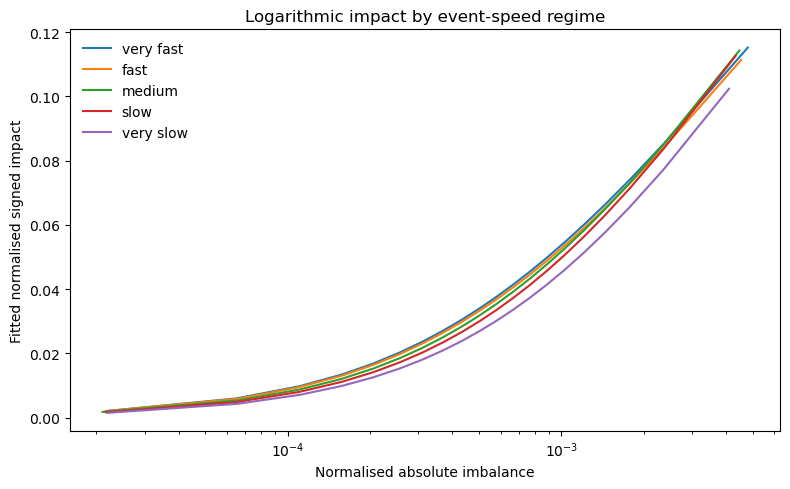

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

for regime in speed_order:
    group = speed_predictions.loc[
        (speed_predictions["event_speed_regime"] == regime)
        & (speed_predictions["model"] == "logarithmic")
    ].sort_values("x")

    ax.plot(
        group["x"],
        group["predicted_impact"],
        label=regime.replace("_", " "),
    )

ax.set_xscale("log")
ax.set_xlabel("Normalised absolute imbalance")
ax.set_ylabel("Fitted normalised signed impact")
ax.set_title("Logarithmic impact by event-speed regime")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [43]:
volume_order = [
    "very_low_volume", "low_volume", "medium_volume", "high_volume", "very_high_volume"
]
volume_curves, _ = bin_impact_by_shared_edges(
    analysis,
    regime_col="volume_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)
volume_model_comparison, volume_predictions, common_volume_curves = compare_impact_models_by_regime(
    volume_curves,
    regime_col="volume_regime",
    regimes=volume_order,
    min_obs_per_bin=200,
    x_scale=pooled_x_scale,
)


In [44]:
regime_summary_vol = (
    volume_model_comparison
    .pivot(
        index="volume_regime",
        columns="model",
        values=[
            "amplitude",
            "delta",
            "curvature",
            "weighted_rmse",
        ],
    )
)

log_A = regime_summary_vol[("amplitude", "logarithmic")]
log_b = regime_summary_vol[("curvature", "logarithmic")]

regime_parameters_vol = pd.DataFrame(
    {
        "log_amplitude": log_A,
        "log_curvature": log_b,
        "log_x0": pooled_x_scale / log_b,
        "free_power_delta": regime_summary_vol[
            ("delta", "free_power")
        ],
        "log_wrmse": regime_summary_vol[
            ("weighted_rmse", "logarithmic")
        ],
        "power_wrmse": regime_summary_vol[
            ("weighted_rmse", "free_power")
        ],
    }
)

regime_parameters_vol["initial_marginal_impact"] = (
    regime_parameters_vol["log_amplitude"]
    / regime_parameters_vol["log_x0"]
)

regime_parameters_vol["initial_effective_liquidity"] = (
    regime_parameters_vol["log_x0"]
    / regime_parameters_vol["log_amplitude"]
)

regime_parameters_vol["log_wrmse_improvement_pct"] = 100 * (
    regime_parameters_vol["power_wrmse"]
    - regime_parameters_vol["log_wrmse"]
) / regime_parameters_vol["power_wrmse"]

regime_parameters_vol

,log_amplitude,log_curvature,log_x0,free_power_delta,log_wrmse,power_wrmse,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
volume_regime,,,,,,,,,
high_volume,0.075935,0.492554,0.001097,0.771487,0.001305,0.001628,69.221997,0.014446,19.823393
low_volume,0.066798,0.681855,0.000792,0.757436,0.001760,0.002169,84.294900,0.011863,18.857826
medium_volume,0.058506,0.777504,0.000695,0.725372,0.001159,0.001607,84.188859,0.011878,27.863587
very_high_volume,0.058114,0.622248,0.000868,0.720228,0.002013,0.002123,66.926093,0.014942,5.184727
very_low_volume,0.050534,1.040883,0.000519,0.718653,0.001019,0.001273,97.349026,0.010272,19.944775


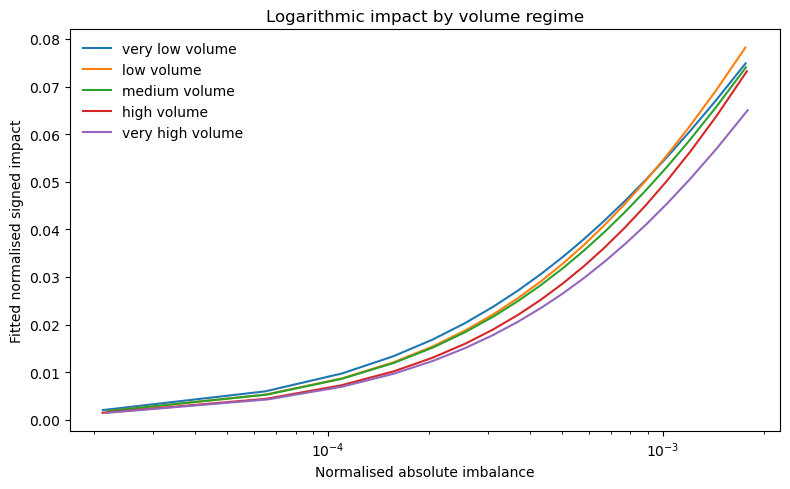

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

for regime in volume_order:
    group = volume_predictions.loc[
        (volume_predictions["volume_regime"] == regime)
        & (volume_predictions["model"] == "logarithmic")
    ].sort_values("x")

    ax.plot(
        group["x"],
        group["predicted_impact"],
        label=regime.replace("_", " "),
    )

ax.set_xscale("log")
ax.set_xlabel("Normalised absolute imbalance")
ax.set_ylabel("Fitted normalised signed impact")
ax.set_title("Logarithmic impact by volume regime")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()